In [ ]:
!pip install colorcet

In [ ]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import torch
import umap
from matplotlib.colors import hsv_to_rgb

import pandas as pd
import re
from collections import defaultdict
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

import os
from gensim.models import Word2Vec
import colorcet as cc

In [18]:
def get_indiv_concepts(formula) -> list:
    concepts = []
    concps = re.findall(r'(?<!\bNOT\s)(?:\b(?:hyp|pre|oth):[^\s)]+)', formula)
    for c in concps:
        try:
            end_idx = c.index(')')
        except:
            end_idx = len(c)
        concepts.append(c[:end_idx])
    return concepts

def load_csv_data(filepath):
    """Load CSV and extract unit-concept mappings."""
    df = pd.read_csv(filepath)
    unit_concepts = defaultdict(set)
    raw_concepts= []
    for _, row in df.iterrows():
        unit = row['unit']
        formula = row['best_name']
        concepts = get_indiv_concepts(formula)
        unit_concepts[unit].update(concepts)
        raw_concepts.extend(concepts)
    return unit_concepts, set(raw_concepts)
 

In [19]:
with open('data/analysis/snli_1.0_dev.tok', 'r') as f:
    samples = f.readlines()
sentences = []
for sentence in samples:
    sentences.append(sentence.split())

In [46]:
w2v = Word2Vec(sentences, vector_size=128, window=5, epochs=10, workers=4, min_count=1)
embeddings=[]
used_words=[]

rels0=[{'old', 'older'}, {'horses', 'horse'}, {'motorcycle', 'bicycle', 'bike'}, {'player', 'football', 'basketball', 'tennis', 'game', 'win', 'baseball', 'racket', 'soccer', 'play', 'frisbee', 'volleyball', 'players', 'hockey', 'team'}, {'nap', 'asleep', 'bed', 'sleep', 'couch'}, {'girl', 'boys', 'boy', 'girls', 'kids', 'family', 'children', 'young', 'child'}, {'vbz', 'vbn', 'vbd', 'vbp', 'nn', 'POS', 'nns', 'vb', 'jj', 'nnp', 'vbg'}, {'nobody', 'something'}, {'black', 'gray', 'blue', 'purple', 'pink', 'white', 'red', 'yellow', 'orange', 'brown', 'green'}, {'catch', 'ball'}, {'suit', 'jeans'}, {'working', 'looking', 'running'}, {'bar', 'coffee'}, {'dog', 'dogs', 'animal', 'cat'}, {'dress', 'wearing'}, {'new', 'another'}, {'wave', 'smiling'}, {'car', 'driving', 'park'}, {'there', 'one', 'as', 'each', 'is', 'alone', 'not', 'because', 'no'}, {'through', 'around', 'into', 'down', 'out', 'on', 'behind'}, {'race', 'racing'}, {'wall', 'brick'}, {'riding', 'ride'}, {'floor', 'room', 'kitchen'}, {'birthday', 'bride', 'party'}, {'woman', 'lady', 'man', 'female', 'men', 'women'}, {'set', 'couple', 'other', 'several', 'lot', 'all', 'about', 'some'}, {'desk', 'table'}, {'skateboarder', 'snowboarder', 'skateboard'}, {'edge', 'in', 'outside', 'front'}, {'sit', 'seated', 'bench'}, {'his', 'she', 'he', 'her'}, {'river', 'lake'}, {'and', 'with'}, {'next', 'while', 'after'}, {'dinner', 'lunch'}, {'sand', 'dirt', 'rocks'}, {'band', 'track', 'music'}, {'acoustic', 'guitar'}, {'crowd', 'audience'}, {'train', 'bus'}, {'human', 'humans'}, {'son', 'mother'}, {',', '.'}, {'three', 'two'}, {'street', 'city'}]
rels68=[{'rain', 'snowy', 'ice', 'snow'}, {'dogs', 'cat', 'dog', 'animal', 'cats'}, {'orange', 'white', 'pink', 'black', 'yellow', 'green', 'brown', 'purple', 'dark', 'blue', 'red'}, {'building', 'project'}, {'table', 'chair', 'desk'}, {'looking', 'working', 'trick', 'running'}, {'skateboarding', 'skateboard', 'skateboarder', 'snowboarding', 'snowboarder'}, {'vbn', 'jj', 'POS', 'nnp', 'nns', 'vbz', 'vbd', 'nn', 'vbp', 'vb', 'vbg'}, {'racket', 'tennis', 'soccer', 'basketball', 'football', 'volleyball', 'frisbee', 'baseball', 'hockey'}, {'phone', 'cellphone'}, {'while', 'after', 'during', 'next'}, {'player', 'play', 'game'}, {'naked', 'asian'}, {'suit', 'jeans'}, {'wife', 'son', 'sisters'}, {'humans', 'human'}, {'bus', 'train'}, {'up', 'into', 'on', 'down'}, {'dinner', 'lunch'}, {'haired', 'blond'}, {'street', 'city'}, {'wearing', 'dress'}, {'road', 'mountain'}, {'classroom', 'school'}, {'nap', 'sleep', 'bed', 'couch', 'asleep'}, {'painting', 'drawing'}, {'horses', 'horse'}, {'riding', 'ride'}, {'older', 'old'}, {'pool', 'outdoors', 'indoor'}, {'is', 'one', 'as', '.', 'there', 'someone', 'no', 'something', 'that', 'alone', 'because', 'nobody', 'just', 'not', ','}, {'children', 'boys', 'young', 'girl', 'kids', 'boy', 'girls'}, {'him', 'his', 'her', 'he'}, {'lady', 'men', 'man', 'female', 'woman', 'women'}, {'lake', 'river'}, {'bike', 'bicycle', 'motorcycle'}, {'dirt', 'sand', 'mud'}, {'with', 'and'}, {'park', 'driving', 'car'}, {'all', 'some', 'other'}, {'room', 'kitchen'}, {'outside', 'in'}, {'cafe', 'restaurant'}, {'racing', 'race'}, {'birthday', 'party'}, {'band', 'music', 'track'}, {'woods', 'tree'}]
rels=[rels0, rels68]

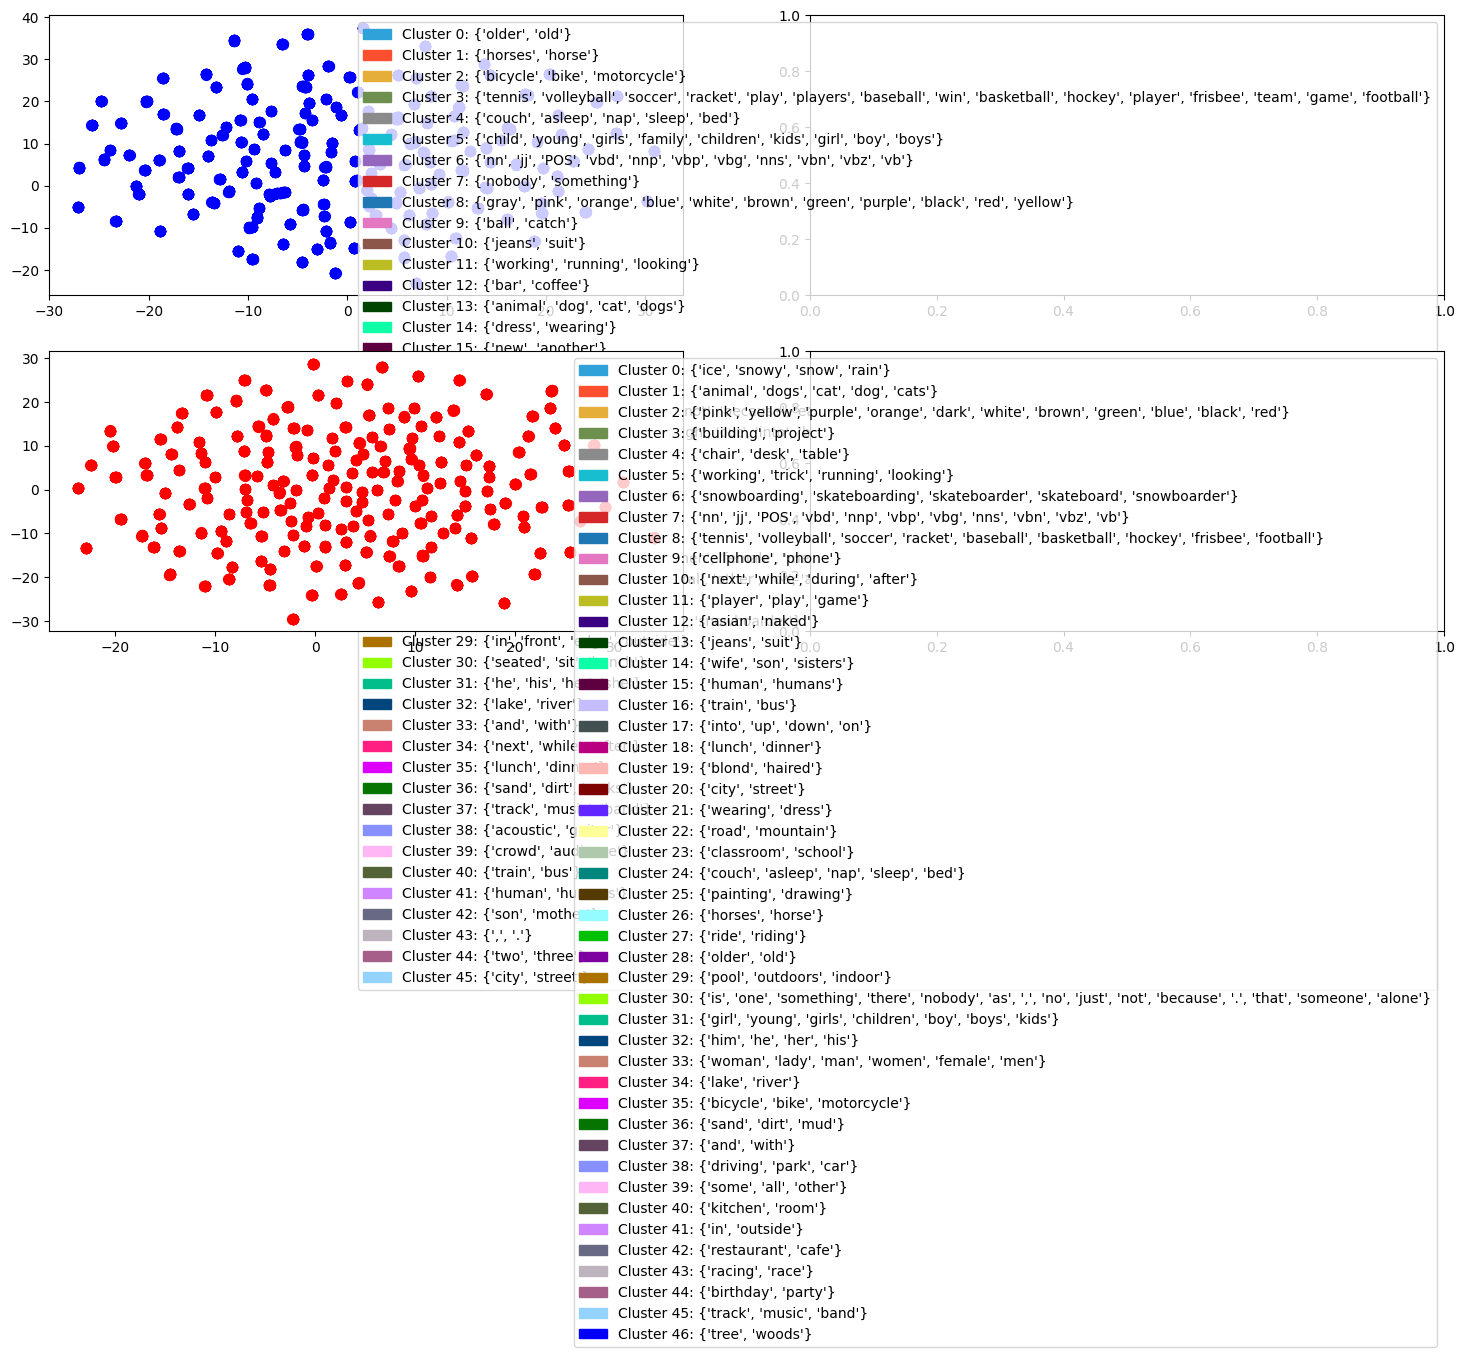

In [53]:

fig, axes = plt.subplots(2, 2, figsize=(18, 8))  # 1 row, 2 columns

# ---- Plot 1 ----
for plot in range(2):
    ax = axes[plot][0]
    #create embeddings 
    rel = rels[plot]
    for group in rel:
        for word in group:
            if word not in w2v.wv.key_to_index: continue
            used_words.append(word)
            embeddings.append(w2v.wv[word])

    #create word:cluster mapping (cluster is concept group cluster not activation cluster)
    word_to_cluster = {}
    for cluster_id, cluster in enumerate(rel):
        for word in cluster:
            word_lower = word.lower()
            word_to_cluster[word_lower] = cluster_id

    # clusterIDs
    labels = [word_to_cluster.get(w, -1) for w in used_words]  # your cluster IDs

    #dimensionality reduction
    reducer = umap.UMAP(n_neighbors=10, min_dist=0.1, n_components=2)
    coords = reducer.fit_transform(embeddings, y=labels)  # supervised

    #create unique colors
    num_clusters = len(rel)
    hues = np.linspace(0, 1, num_clusters, endpoint=False)

    colors_list = cc.glasbey_hv[0:num_clusters]
    clus_to_col = {i:j for i,j in enumerate(colors_list)}

    # Assign colors to words
    colors = [colors_list[word_to_cluster.get(w, -1)] for w in used_words]


    for (x, y), w, c in zip(coords, used_words, colors):
        ax.scatter(x, y, color=c, s=50)
        #ax.text(x, y, w, fontsize=8)

    #ax.title("2D Word Embedding Plot (Clustered Concepts)")


    #plot legend (which colors to which cluster)
    from matplotlib.patches import Patch
    legend_elements = []
    for cluster_id, cluster in enumerate(rel):
        legend_elements.append(Patch(color=colors_list[cluster_id], label=f'Cluster {cluster_id}: {rel[cluster_id]}'))
    ax = axes[plot][1]
    ax.legend(handles=legend_elements, loc='best', fontsize=10)
    #ax.title("Word Embedding Visualization with Cluster Colors")
plt.show()

